# E16 · Showing uncertainty: one posterior, twenty displays

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Motorcycle crash test (133 readings) · Minnesota radon survey (919 homes, 85 counties, with county boundaries) · English Premier League 2024/25 (380 matches) |
| **You will learn** | Why a 94% band is not a set of curves · epistemic vs predictive bands · fan charts · spaghetti and **hypothetical outcome plots (animation)** · quantile dotplots · exceedance curves · caterpillars with shrinkage · ridgelines · **maps** of the mean, of the uncertainty, hatching, bivariate and **value-suppressing palettes**, exceedance maps, small-multiple and **animated draw maps** · icon arrays · rank-probability heatmaps · pairwise "who is better" matrices · **re-simulated seasons** · uncertainty in a table · interactive **plotly** figures with hover · which display answers which question |

A posterior is a probability distribution over everything you did not know. A figure keeps
one or two of its dimensions and throws the rest away, and *which* dimensions it keeps is a
modelling decision as real as the choice of prior. The literature on how people read
uncertainty displays (Spiegelhalter 2011; Hullman, Resnick & Adar 2015; Kay et al. 2016;
Correll, Moritz & Heer 2018; Padilla, Kay & Hullman 2021) has a few robust findings:

- readers treat a **line** as the truth and a **band edge** as a cliff (the "deterministic
  construal error"), so a single 94% band does not communicate much uncertainty at all;
- **frequency framings** - dots you can count, outcomes you can watch happen - are read far
  more accurately than densities or intervals, even by experts;
- a display of the **estimate** and a display of its **uncertainty** are two different
  figures; putting both in one needs a palette designed for it;
- the question the reader brings ("will my basement exceed the action level?", "who is the
  best team?") decides the display, not the model. The same posterior needs a different
  figure for every question.

This notebook fits three quick models and then spends its time on the displays: matplotlib
throughout, seaborn for heatmaps, `matplotlib.animation` and plotly for animation, plotly
for maps and hover, and a pandas `Styler` for the case where a table is the right figure.
The plotly figures are interactive in JupyterLab or VS Code (they load plotly.js from a
CDN, so a rendered copy needs a network connection to show them; GitHub's viewer will not).

In [1]:
import json
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import preliz as pz
import pymc as pm
import seaborn as sns
import xarray as xr
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import PolyCollection
from matplotlib.colors import to_rgb
from matplotlib.patches import Ellipse, Rectangle
from pymc.model.transform.optimization import freeze_dims_and_data
from scipy.stats import gaussian_kde

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
pio.renderers.default = "plotly_mimetype+notebook_connected"

# A fixed categorical order (never cycled) and one sequential hue per quantity: blue for the
# crash curve, orange for radon, purple for uncertainty, a diverging pair only for "who beats whom".
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def stacked(da: xr.DataArray) -> np.ndarray:
    """(chain, draw, ...) -> (sample, ...) NumPy array."""
    return da.stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Three posteriors in under a minute

The models are not the lesson here, so they are taken from earlier notebooks with as little
ceremony as possible. Each gives a different *kind* of posterior:

| | Model | Posterior over | Displays it calls for |
|---|---|---|---|
| **A** | heteroskedastic Hilbert-space GP on the motorcycle crash data (E05) | a **function** and its noise | bands, fans, spaghetti, animation, dotplots, exceedance curves |
| **B** | hierarchical radon model with county uranium (E02) | **85 groups** that live on a map | caterpillars, ridgelines, maps of every kind |
| **C** | Poisson goals model for the 2024/25 Premier League | **team strengths** and a **ranking** | rank heatmaps, pairwise matrices, re-simulated seasons, tables |

### A · A curve with two kinds of uncertainty

In [2]:
data.describe("mcycle")
mcycle = data.load("mcycle")
t = mcycle.times.to_numpy()
ACCEL_SD = mcycle.accel.std()
y_crash = mcycle.accel.to_numpy() / ACCEL_SD
t_grid = np.linspace(0, 60, 121)

ell_prior = pz.maxent(pz.InverseGamma(), lower=3, upper=25, mass=0.9, plot=False)
m_rec, c_rec = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[t.min(), t.max()], lengthscale_range=[3, 25], cov_func="matern52"
)

with pm.Model() as crash_model:
    X = pm.Data("X", t[:, None])
    ell = pm.InverseGamma("ell", alpha=float(ell_prior.alpha), beta=float(ell_prior.beta))
    eta = pm.HalfNormal("eta", 1.5)
    gp_f = pm.gp.HSGP(m=[m_rec], c=c_rec, parametrization="centered",
                      cov_func=eta**2 * pm.gp.cov.Matern52(1, ls=ell))
    f = gp_f.prior("f", X=X)  # the mean curve: epistemic uncertainty
    ell_g = pm.InverseGamma("ell_g", alpha=float(ell_prior.alpha), beta=float(ell_prior.beta))
    eta_g = pm.HalfNormal("eta_g", 1.5)
    s0 = pm.Normal("s0", -1, 1)
    gp_g = pm.gp.HSGP(m=[m_rec], c=c_rec, parametrization="noncentered",
                      cov_func=eta_g**2 * pm.gp.cov.Matern52(1, ls=ell_g))
    g = gp_g.prior("g", X=X)
    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(s0 + g))  # the noise level: aleatoric
    pm.Normal("y", f, sigma_t, observed=y_crash, shape=f.shape)

with freeze_dims_and_data(crash_model):
    crash_idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
with crash_model:
    pm.set_data({"X": t_grid[:, None]})
    crash_pred = pm.sample_posterior_predictive(
        crash_idata, var_names=["f", "sigma_t", "y"], predictions=True,
        random_seed=RANDOM_SEED, progressbar=False,
    )

print("divergences:", int(crash_idata.sample_stats["diverging"].sum()))
az.summary(crash_idata, var_names=["ell", "eta", "ell_g", "eta_g", "s0"], round_to=2)

mcycle: Head acceleration (g) against time after impact (ms), 133 readings.
  source: Silverman (1985), simulated motorcycle crash experiment, via R package `MASS`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/MASS/mcycle.csv


NUTS[nutpie]: [eta_g, ell_g, g_hsgp_coeffs, s0, eta, ell, f_hsgp_coeffs]


Sampling: [y]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,7.61,1.62,5.35,10.45,308.14,523.33,1.02,0.09,0.05
eta,1.15,0.37,0.69,1.83,866.64,1260.66,1.01,0.01,0.01
ell_g,9.06,2.57,5.51,13.59,3549.18,2689.39,1.00,0.04,0.04
eta_g,1.48,0.48,0.88,2.35,2654.19,2362.08,1.00,0.01,0.01
s0,-1.40,0.63,-2.38,-0.37,4025.38,2922.49,1.00,0.01,0.01


In [3]:
# Everything in g from here on: F is the mean curve, Y a new reading, both (sample, t_grid).
F = stacked(crash_pred.predictions["f"]) * ACCEL_SD
Y = stacked(crash_pred.predictions["y"]) * ACCEL_SD
accel = mcycle.accel.to_numpy()
print(F.shape, Y.shape)

(4000, 121) (4000, 121)


### B · Eighty-five counties on a map

In [4]:
data.describe("radon")
data.describe("us_counties_geojson")
radon = data.load("radon")
counties = np.sort(radon.county.unique())
county_idx = pd.Index(counties).get_indexer(radon.county)
log_u = np.log(radon.groupby("county").Uppm.first().loc[counties].to_numpy())
n_homes = radon.groupby("county").size().loc[counties].to_numpy()
county_fips = radon.groupby("county").fips.first().loc[counties].astype(int).to_numpy()

with pm.Model(coords={"county": counties, "obs": radon.index}) as radon_model:
    county_id = pm.Data("county_id", county_idx, dims="obs")
    floor_d = pm.Data("floor", radon.floor.to_numpy().astype(float), dims="obs")
    log_u_d = pm.Data("log_u", log_u, dims="county")
    gamma_0 = pm.Normal("gamma_0", 1, 2)
    gamma_1 = pm.Normal("gamma_1", 0, 1)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1)
    z = pm.Normal("z", 0, 1, dims="county")
    alpha = pm.Deterministic("alpha", gamma_0 + gamma_1 * log_u_d + sigma_alpha * z, dims="county")
    beta = pm.Normal("beta", 0, 1)
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", alpha[county_id] + beta * floor_d, sigma,
              observed=radon.log_radon.to_numpy(), dims="obs")
    radon_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

print("divergences:", int(radon_idata.sample_stats["diverging"].sum()))
az.summary(radon_idata, var_names=["gamma_0", "gamma_1", "sigma_alpha", "beta", "sigma"], round_to=2)

NUTS[nutpie]: [gamma_0, gamma_1, sigma_alpha, z, beta, sigma]


radon: Log radon measurements in 919 Minnesota homes across 85 counties.
  source: US EPA State Residential Radon Survey (Minnesota subset), via Gelman & Hill (2007).
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/radon.csv
us_counties_geojson: GeoJSON of every US county keyed by 5-digit FIPS code. Not a table: use data.path().
  source: US Census Bureau county boundaries (simplified), as distributed in plotly/datasets.
  url:    https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gamma_0,1.49,0.04,1.44,1.56,1826.07,2349.54,1.0,0.0,0.0
gamma_1,0.69,0.09,0.55,0.84,2186.25,2218.47,1.0,0.0,0.0
sigma_alpha,0.15,0.05,0.07,0.23,823.35,1015.06,1.0,0.0,0.0
beta,-0.64,0.07,-0.75,-0.53,3307.23,2828.06,1.0,0.0,0.0
sigma,0.73,0.02,0.70,0.76,3713.30,2636.06,1.0,0.0,0.0


In [5]:
# County geometric-mean basement radon in pCi/L, (sample, county). The EPA action level is 4.
GM = np.exp(stacked(radon_idata.posterior["alpha"]))
SIGMA = stacked(radon_idata.posterior["sigma"])
gm_mean = GM.mean(0)
gm_lo, gm_hi = np.quantile(GM, [0.05, 0.95], axis=0)
p_over4 = (GM > 4).mean(0)
raw_gm = np.exp(radon[radon.floor == 0].groupby("county").log_radon.mean()).reindex(counties)
print(f"county GM: {gm_mean.min():.1f} to {gm_mean.max():.1f} pCi/L; "
      f"90% interval widths {np.min(gm_hi - gm_lo):.1f} to {np.max(gm_hi - gm_lo):.1f}")

county GM: 2.4 to 6.7 pCi/L; 90% interval widths 0.6 to 3.5


### C · Twenty teams and a ranking

Goals scored by each side in a match are Poisson with a log-rate built from an attack and a
defence strength per team (both `ZeroSumNormal`, so they are relative to the league) and a
home advantage. The 2024/25 season is complete, so we also know the true final table - the
question the posterior answers is *how much of that table was strength and how much luck*.

In [6]:
data.describe("epl_2425")
epl = data.load("epl_2425")
teams = np.sort(epl.HomeTeam.unique())
home_i = pd.Index(teams).get_indexer(epl.HomeTeam)
away_i = pd.Index(teams).get_indexer(epl.AwayTeam)

with pm.Model(coords={"team": teams, "match": epl.index}) as epl_model:
    intercept = pm.Normal("intercept", 0.2, 0.5)
    home_adv = pm.Normal("home_adv", 0.2, 0.3)
    sd_att = pm.HalfNormal("sd_att", 0.5)
    sd_def = pm.HalfNormal("sd_def", 0.5)
    att = pm.ZeroSumNormal("att", sigma=sd_att, dims="team")
    dfn = pm.ZeroSumNormal("def", sigma=sd_def, dims="team")
    pm.Deterministic("strength", att + dfn, dims="team")
    lam_h = pm.Deterministic("lam_h", pm.math.exp(intercept + home_adv + att[home_i] - dfn[away_i]), dims="match")
    lam_a = pm.Deterministic("lam_a", pm.math.exp(intercept + att[away_i] - dfn[home_i]), dims="match")
    pm.Poisson("home_goals", lam_h, observed=epl.FTHG.to_numpy(), dims="match")
    pm.Poisson("away_goals", lam_a, observed=epl.FTAG.to_numpy(), dims="match")
    epl_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

print("divergences:", int(epl_idata.sample_stats["diverging"].sum()))
az.summary(epl_idata, var_names=["intercept", "home_adv", "sd_att", "sd_def"], round_to=2)

NUTS[nutpie]: [intercept, home_adv, sd_att, sd_def, att, def]


epl_2425: All 380 match results with goals, shots and bookmaker odds.
  source: football-data.co.uk, English Premier League 2024/25.
  url:    https://www.football-data.co.uk/mmz4281/2425/E0.csv


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.30,0.04,0.23,0.37,3099.70,3305.58,1.0,0.0,0.0
home_adv,0.07,0.06,-0.02,0.16,3397.99,3311.46,1.0,0.0,0.0
sd_att,0.25,0.06,0.17,0.35,2461.43,2388.91,1.0,0.0,0.0
sd_def,0.22,0.05,0.14,0.31,2381.99,2278.37,1.0,0.0,0.0


In [7]:
def league_table(gh, ga):
    """Points, goal difference and goals for each team from home/away goals of shape (..., match)."""
    H = np.eye(len(teams))[home_i]  # (match, team) one-hot
    A = np.eye(len(teams))[away_i]
    hp = 3 * (gh > ga) + (gh == ga)
    ap = 3 * (ga > gh) + (gh == ga)
    pts = hp @ H + ap @ A
    gd = (gh - ga) @ H + (ga - gh) @ A
    gf = gh @ H + ga @ A
    return pts, gd, gf


def ranks_from(pts, gd, gf):
    """Final position (1 = champion) for each team, ties broken by goal difference then goals."""
    order = np.lexsort((-gf, -gd, -pts), axis=-1)  # last key is primary
    r = np.empty_like(order)
    np.put_along_axis(r, order, np.arange(1, len(teams) + 1) + 0 * order, axis=-1)
    return r


actual_pts, actual_gd, actual_gf = league_table(epl.FTHG.to_numpy(), epl.FTAG.to_numpy())
actual_pos = ranks_from(actual_pts, actual_gd, actual_gf)
finish_order = teams[np.argsort(actual_pos)]  # champion first
STRENGTH = stacked(epl_idata.posterior["strength"])
print("2024/25 final table (top 6):", ", ".join(f"{tm} {int(actual_pts[i])}" for tm, i in
      zip(finish_order[:6], np.argsort(actual_pos)[:6])))

2024/25 final table (top 6): Liverpool 84, Arsenal 74, Man City 71, Chelsea 69, Newcastle 66, Aston Villa 66


## 2 · One curve, many uncertainties

### 2.1 The band you were going to draw - and the one you should draw next to it

The reflex is mean curve plus a 94% band. But the band of *which* quantity? The posterior of
the mean curve $f(t)$ says where the average acceleration is; the posterior predictive of a
new reading $y(t)$ says where the next data point will be. In this model the second includes
the first plus a noise level that itself changes with time. They answer different questions
and a reader who sees only one of them will assume it is the other.

{'f': '45% of the data inside the 94% band', 'y': '98% of the data inside the 94% band'}


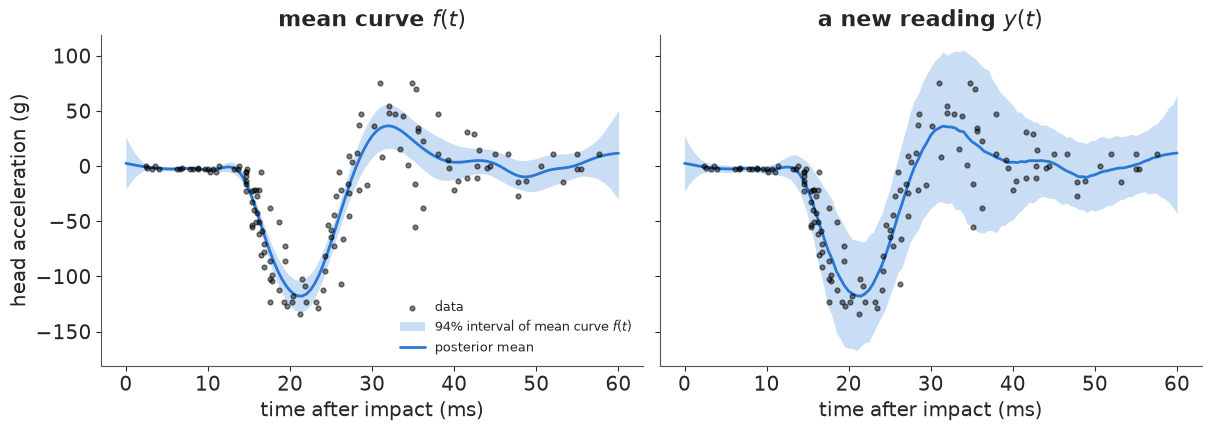

In [8]:
def band(ax, x, samples, prob, color, alpha, label=None, **kw):
    lo, hi = np.quantile(samples, [(1 - prob) / 2, (1 + prob) / 2], axis=0)
    ax.fill_between(x, lo, hi, color=color, alpha=alpha, lw=0, label=label, **kw)
    return lo, hi


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, S, what in [(axes[0], F, "mean curve $f(t)$"), (axes[1], Y, "a new reading $y(t)$")]:
    ax.scatter(t, accel, s=12, color="k", alpha=0.5, zorder=3, label="data")
    band(ax, t_grid, S, 0.94, BLUE, 0.25, label=f"94% interval of {what}")
    ax.plot(t_grid, S.mean(0), color=BLUE, lw=2, label="posterior mean")
    ax.set(xlabel="time after impact (ms)", title=what)
axes[0].set_ylabel("head acceleration (g)")
axes[0].legend(loc="lower right", fontsize=9)

# How much of the data does each band contain? Interpolate the bands to the data times.
inside = {}
for name, S in [("f", F), ("y", Y)]:
    lo, hi = np.quantile(S, [0.03, 0.97], axis=0)
    inside[name] = np.mean((accel >= np.interp(t, t_grid, lo)) & (accel <= np.interp(t, t_grid, hi)))
print({k: f"{v:.0%} of the data inside the 94% band" for k, v in inside.items()})

The left band holds well under half the data; that is not a failure, it is a band around a
*mean*. Label which one you are showing, every time. When the reader's question is "what
will happen", the right-hand plot is the one they need.

### 2.2 Fan charts: make the band edge stop being a cliff

Nested quantile bands at several levels (the Bank of England's "fan chart") show that
probability thins out gradually. One hue, darker in the middle: never a rainbow, and never a
second hue for the outer band or readers will look for a second meaning.

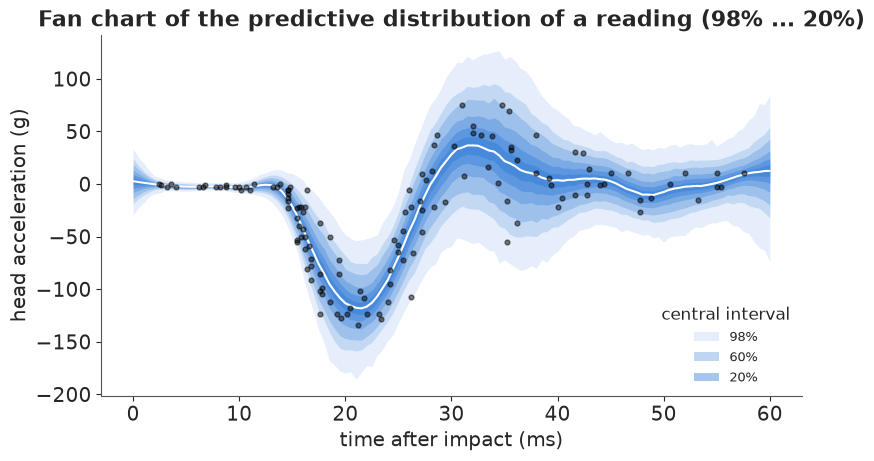

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(t, accel, s=12, color="k", alpha=0.5, zorder=3)
levels = [0.98, 0.9, 0.8, 0.6, 0.4, 0.2]
for i, p in enumerate(levels):
    band(ax, t_grid, Y, p, BLUE, 0.12 + 0.06 * i, label=f"{p:.0%}" if p in (0.98, 0.6, 0.2) else None)
ax.plot(t_grid, np.median(Y, axis=0), color="white", lw=1.5)
ax.set(xlabel="time after impact (ms)", ylabel="head acceleration (g)",
       title="Fan chart of the predictive distribution of a reading (98% ... 20%)")
ax.legend(title="central interval", loc="lower right", fontsize=9);

### 2.3 The band is not a set of curves

A pointwise band is the union of intervals computed one $t$ at a time. Its **edges are not
possible curves** - no draw hugs the lower edge along its whole length - and the band says
nothing about how the curve at 20 ms is related to the curve at 30 ms. Spaghetti plots show
what the band hides: individual draws are rougher, and their features (where the trough is,
how deep) vary in ways a band cannot express.

P(trough deeper than the band's lowest point) = 0.036
trough time: median 21.0 ms, 90% interval 20.5-22.0 ms


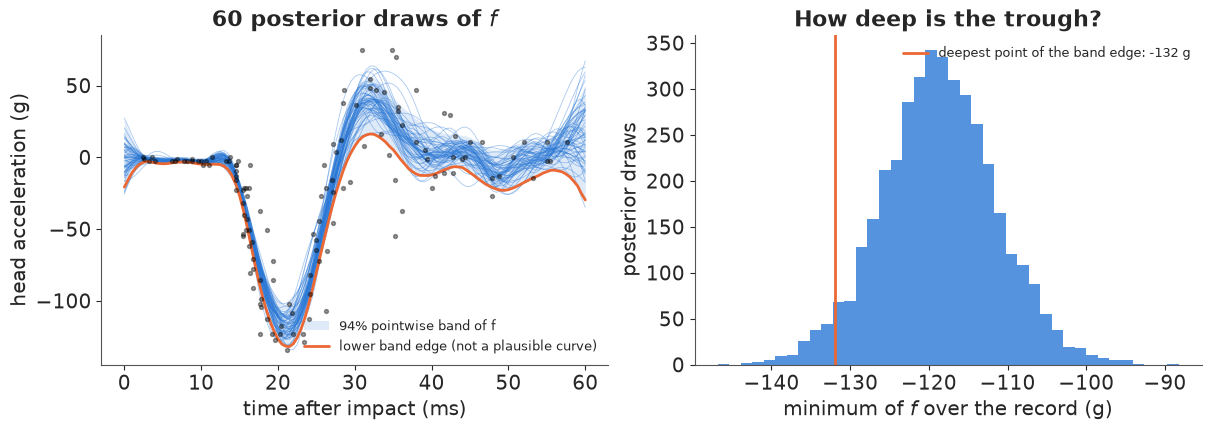

In [10]:
lo94, hi94 = np.quantile(F, [0.03, 0.97], axis=0)
idx = rng.choice(F.shape[0], 60, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.fill_between(t_grid, lo94, hi94, color=BLUE, alpha=0.15, lw=0, label="94% pointwise band of f")
ax.plot(t_grid, F[idx].T, color=BLUE, lw=0.6, alpha=0.4)
ax.plot(t_grid, lo94, color=ORANGE, lw=2, label="lower band edge (not a plausible curve)")
ax.scatter(t, accel, s=8, color="k", alpha=0.4, zorder=3)
ax.set(xlabel="time after impact (ms)", ylabel="head acceleration (g)", title="60 posterior draws of $f$")
ax.legend(loc="lower right", fontsize=9)

# Feature uncertainty: the depth and the timing of the trough, per draw.
trough_depth = F.min(axis=1)
trough_time = t_grid[F.argmin(axis=1)]
ax = axes[1]
ax.hist(trough_depth, bins=40, color=BLUE, alpha=0.8)
ax.axvline(lo94.min(), color=ORANGE, lw=2, label=f"deepest point of the band edge: {lo94.min():.0f} g")
ax.set(xlabel="minimum of $f$ over the record (g)", ylabel="posterior draws", title="How deep is the trough?")
ax.legend(fontsize=9)
print(f"P(trough deeper than the band's lowest point) = {(trough_depth < lo94.min()).mean():.3f}")
print(f"trough time: median {np.median(trough_time):.1f} ms, 90% interval "
      f"{np.quantile(trough_time, 0.05):.1f}-{np.quantile(trough_time, 0.95):.1f} ms")

The band's lowest point is a depth that fewer than 4% of posterior curves ever reach, and
no curve reaches it *while also* following the rest of the edge. Anyone reading the band
as "the curve could be this low at the trough" is misled by the construction. If a *feature* of the curve matters (its minimum, its crossing time, its slope
at a point) compute the posterior of that feature - the right panel - rather than eyeballing
it from a band.

### 2.4 Hypothetical outcome plots: animate the draws

Hullman, Resnick & Adar (2015) showed that people judge probabilities from a sequence of
hypothetical outcomes - one draw at a time, shown for a few hundred milliseconds - better
than from error bars or violins, because a distribution becomes something you *experience*
rather than decode. Here `matplotlib.animation` cycles through posterior draws of the
predictive distribution; `to_jshtml()` embeds the frames with a play/pause control, so the
notebook needs no video codec.

In [11]:
n_frames = 40
frame_idx = rng.choice(Y.shape[0], n_frames, replace=False)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=72)  # 40 embedded frames: keep them small
ax.fill_between(t_grid, *np.quantile(Y, [0.05, 0.95], axis=0), color=BLUE, alpha=0.1, lw=0)
ax.scatter(t, accel, s=12, color="k", alpha=0.35, zorder=3)
(curve,) = ax.plot(t_grid, F[frame_idx[0]], color=BLUE, lw=2)
dots = ax.scatter(t_grid[::3], Y[frame_idx[0], ::3], s=18, color=ORANGE, zorder=4)
title = ax.set_title("posterior draw 1 of 40")
ax.set(xlabel="time after impact (ms)", ylabel="head acceleration (g)", ylim=(-220, 120))
plt.close(fig)  # keep the static figure out of the output; the animation is shown below


def update(i):
    curve.set_ydata(F[frame_idx[i]])
    dots.set_offsets(np.c_[t_grid[::3], Y[frame_idx[i], ::3]])
    title.set_text(f"posterior draw {i + 1} of 40")
    return curve, dots, title


hops = animation.FuncAnimation(fig, update, frames=n_frames, interval=400, blit=False)
HTML(hops.to_jshtml(default_mode="loop"))

Two things to watch for as it plays. The blue curve barely moves after 10 ms and wobbles a
lot before 40 ms; that *is* the posterior of $f$, in a form no band can show, including the
fact that draws are smooth (they come from a GP with a lengthscale near 8 ms). The orange
readings jump about far more than the curve, and by a different amount at different times -
the heteroskedastic noise. About 400 ms per frame is the rate the literature recommends;
faster and the frames blur into a band again. Animations are not accessible to everyone
and cannot be printed, so section 2.5 and the small multiples in 3.3 are the static
alternatives.

### 2.5 Quantile dotplots: an uncertainty you can count

Kay, Kola, Hullman & Munson (2016) replaced a density with a fixed number of dots placed at
the distribution's quantiles. "How likely is a reading below -100 g at 20 ms?" becomes
"count the dots left of the line": 20 dots make every dot 5%. Readers got this right far
more often than with a density, and it survives being printed small.

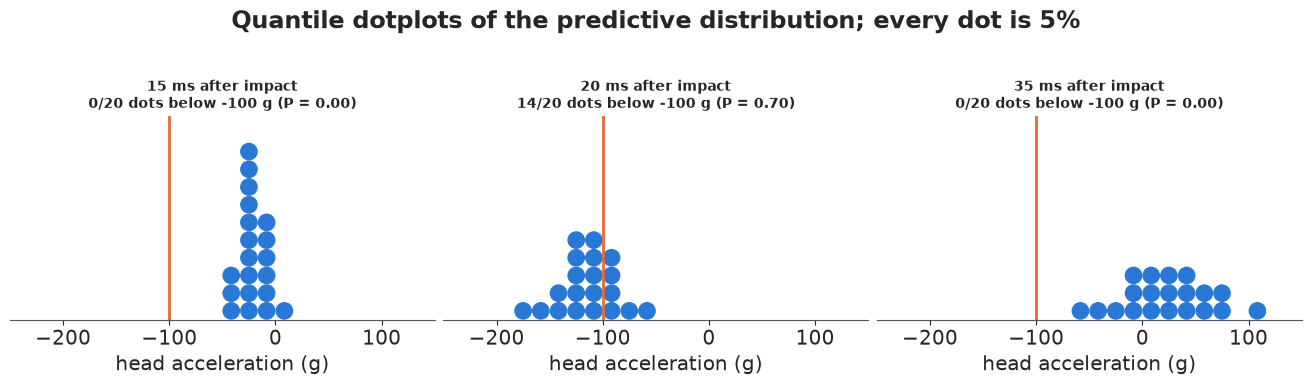

In [12]:
def quantile_dotplot(ax, samples, n_dots=20, n_bins=24, color=BLUE, xlim=None, max_stack=12):
    """Wilkinson-style dotplot of the n_dots quantiles of `samples`, stacked in n_bins columns."""
    q = np.quantile(samples, (np.arange(n_dots) + 0.5) / n_dots)
    lo, hi = xlim if xlim is not None else (q.min(), q.max())
    edges = np.linspace(lo, hi, n_bins + 1)
    width = edges[1] - edges[0]
    cols = np.clip(np.digitize(q, edges) - 1, 0, n_bins - 1)
    heights = np.zeros(n_bins, int)
    for c in cols:
        ax.add_patch(Ellipse((edges[c] + width / 2, heights[c] + 0.5), width * 0.92, 0.92, color=color))
        heights[c] += 1
    ax.set(xlim=(lo, hi), ylim=(0, max_stack + 0.5), yticks=[])
    ax.set_aspect(width)  # one dot diameter = one bin width, so the dots are round
    sns.despine(ax=ax, left=True)
    return q


fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, t0 in zip(axes, [15, 20, 35]):
    j = np.argmin(np.abs(t_grid - t0))
    q = quantile_dotplot(ax, Y[:, j], xlim=(-250, 150), max_stack=11)
    ax.axvline(-100, color=ORANGE, lw=2)
    n_below = int((q < -100).sum())
    ax.set(xlabel="head acceleration (g)")
    ax.set_title(f"{t0} ms after impact\n{n_below}/20 dots below -100 g (P = {(Y[:, j] < -100).mean():.2f})", fontsize=10)
fig.suptitle("Quantile dotplots of the predictive distribution; every dot is 5%", y=1.02);

### 2.6 Exceedance curves: give the reader the probability they asked for

If the question is "how likely is a value beyond a threshold", plot **that probability**
directly, as a function of the input. It removes every step of decoding. Note again the two
quantities: the probability that the *mean* is below -100 g reaches almost 1 near 20 ms;
the probability that a *reading* is below -100 g never gets that high.

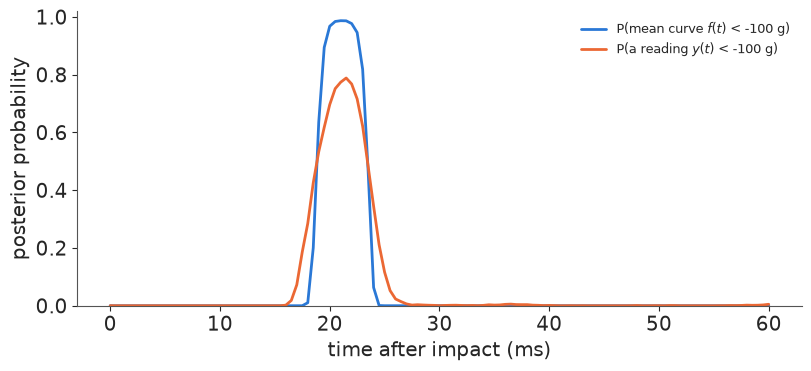

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(t_grid, (F < -100).mean(0), color=BLUE, lw=2, label="P(mean curve $f(t)$ < -100 g)")
ax.plot(t_grid, (Y < -100).mean(0), color=ORANGE, lw=2, label="P(a reading $y(t)$ < -100 g)")
ax.set(xlabel="time after impact (ms)", ylabel="posterior probability", ylim=(0, 1.02))
ax.legend(loc="upper right", fontsize=9);

### 2.7 Interactive: the fan chart with the numbers on hover

In a live notebook a plotly figure can carry all of the above at once: the fan for the
shape, and the exact quantiles and exceedance probability for any $t$ on hover. Static
readers still get the fan. (Hover reads best with `hovermode="x unified"`.)

In [14]:
qs = np.quantile(Y, [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99], axis=0)
p_below = (Y < -100).mean(0)
fig = go.Figure()
for (lo_i, hi_i, name, a) in [(0, 6, "98%", 0.12), (1, 5, "90%", 0.18), (2, 4, "50%", 0.3)]:
    fig.add_trace(go.Scatter(x=t_grid, y=qs[lo_i], line=dict(width=0), showlegend=False, hoverinfo="skip"))
    fig.add_trace(go.Scatter(x=t_grid, y=qs[hi_i], fill="tonexty", fillcolor=f"rgba(42,120,214,{a})",
                             line=dict(width=0), name=f"{name} interval", hoverinfo="skip"))
fig.add_trace(go.Scatter(
    x=t_grid, y=qs[3], name="median", line=dict(color=BLUE, width=2),
    customdata=np.c_[qs[1], qs[5], p_below],
    hovertemplate="median %{y:.0f} g<br>90%%: %{customdata[0]:.0f} to %{customdata[1]:.0f} g"
                  "<br>P(< -100 g) = %{customdata[2]:.2f}<extra></extra>",
))
fig.add_trace(go.Scatter(x=t, y=accel, mode="markers", name="data",
                         marker=dict(color="black", size=5, opacity=0.5), hoverinfo="skip"))
fig.update_layout(hovermode="x unified", template="plotly_white", width=800, height=420,
                  xaxis_title="time after impact (ms)", yaxis_title="head acceleration (g)",
                  legend=dict(orientation="h", y=-0.2))
fig

## 3 · Eighty-five posteriors at once: groups and maps

### 3.1 Caterpillar plots and shrinkage

With many groups the first display is a caterpillar: every county's posterior, sorted. Two
nested intervals per county (50% thick, 90% thin) read better than one, and showing the raw
county mean next to the posterior shows the *shrinkage* - counties with one or two homes are
pulled a long way towards what their uranium level predicts. `az.plot_forest` gives the
same thing unsorted; this one is worth building by hand.

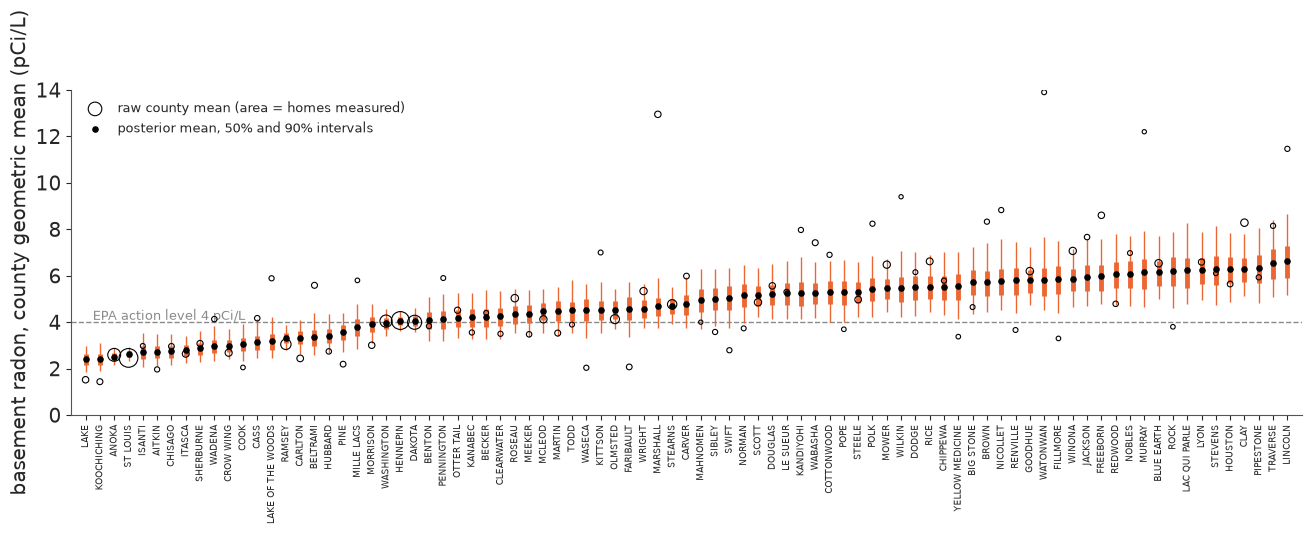

In [15]:
order = np.argsort(gm_mean)
q25, q75 = np.quantile(GM, [0.25, 0.75], axis=0)
x = np.arange(len(counties))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axhline(4, color=GREY, lw=1, ls="--")
ax.text(0.5, 4.1, "EPA action level 4 pCi/L", color=GREY, fontsize=9)
ax.vlines(x, gm_lo[order], gm_hi[order], color=ORANGE, lw=1)
ax.vlines(x, q25[order], q75[order], color=ORANGE, lw=3.5)
ax.scatter(x, raw_gm.to_numpy()[order], s=8 + 1.5 * n_homes[order], facecolor="none",
           edgecolor="k", lw=0.8, zorder=3, label="raw county mean (area = homes measured)")
ax.scatter(x, gm_mean[order], s=14, color="k", zorder=4, label="posterior mean, 50% and 90% intervals")
ax.set(xticks=x, xlim=(-1, len(counties)), ylim=(0, 14), ylabel="basement radon, county geometric mean (pCi/L)")
ax.set_xticklabels(counties[order], rotation=90, fontsize=6.5)
ax.legend(loc="upper left", fontsize=9);

### 3.2 Ridgelines: the shape, when the shape matters

Intervals hide skew and multimodality. Ridgelines (stacked densities) show the full shape
for a manageable number of groups. Here the 8 counties with the most homes and the 8 with
the fewest; the width of each ridge is the sample size made visible.

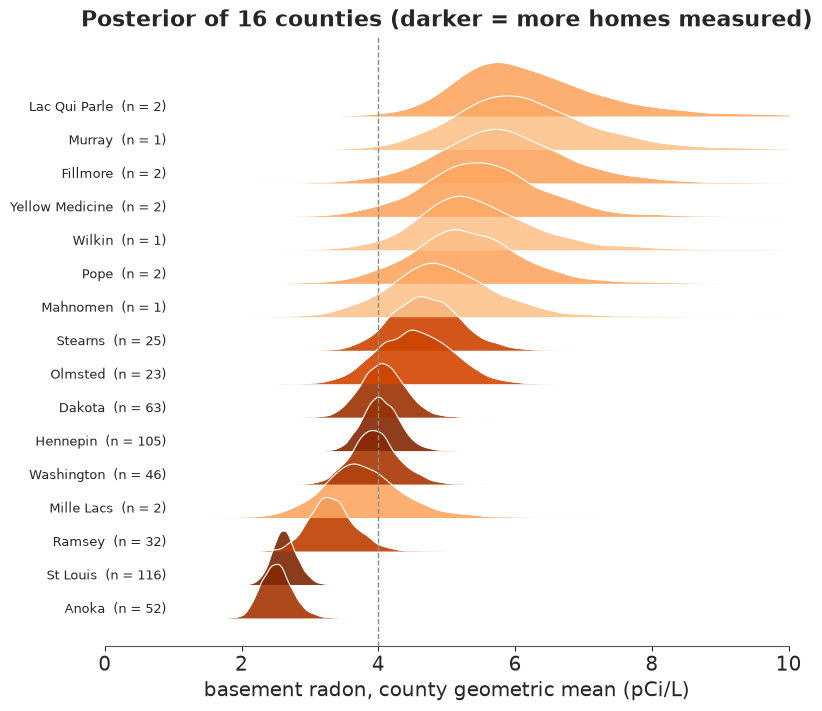

In [16]:
pick = np.r_[np.argsort(n_homes)[-8:], np.argsort(n_homes)[:8]]
pick = pick[np.argsort(gm_mean[pick])]
grid = np.linspace(1, 10, 300)
cmap = plt.get_cmap("Oranges")
n_norm = plt.Normalize(0, np.log(n_homes.max()))

fig, ax = plt.subplots(figsize=(8, 7))
for k, i in enumerate(pick):
    dens = gaussian_kde(GM[:, i])(grid)
    dens = dens / dens.max() * 1.6
    ax.fill_between(grid, k, k + dens, color=cmap(0.3 + 0.7 * n_norm(np.log(n_homes[i]))), alpha=0.9, lw=0)
    ax.plot(grid, k + dens, color="white", lw=0.8)
    ax.text(0.9, k + 0.15, f"{counties[i].title()}  (n = {n_homes[i]})", ha="right", fontsize=9)
ax.axvline(4, color=GREY, lw=1, ls="--")
ax.set(xlim=(0, 10), yticks=[], xlabel="basement radon, county geometric mean (pCi/L)",
       title="Posterior of 16 counties (darker = more homes measured)")
sns.despine(ax=ax, left=True);

### 3.3 Maps

County boundaries come from the Census GeoJSON registered in `data.py`; matplotlib can draw
polygons straight from it with a `PolyCollection`, no GIS library required. Two counties
(Grant and Red Lake) have no radon measurements: the model *could* predict them from their
uranium if we had it, but we do not, so they are "unknown" - which is a different thing
from "uncertain" and gets its own hatched grey.

In [17]:
geo = json.load(open(data.path("us_counties_geojson")))
mn = {int(ft["id"]): ft for ft in geo["features"] if ft["id"].startswith("27")}
polys = {fips: np.array(ft["geometry"]["coordinates"][0]) for fips, ft in mn.items()}
missing_fips = sorted(set(mn) - set(county_fips))
print("counties without data:", [mn[f]["properties"]["NAME"] for f in missing_fips])


def draw_map(ax, values, cmap, norm=None, title="", cbar_label="", hatch_mask=None, hatch="////"):
    """Choropleth of one value per county (in `counties` order) on `ax`; returns the collection."""
    pc = PolyCollection([polys[f] for f in county_fips], array=np.asarray(values), cmap=cmap, norm=norm,
                        edgecolor="white", linewidth=0.4)
    ax.add_collection(pc)
    ax.add_collection(PolyCollection([polys[f] for f in missing_fips], facecolor="#dddddd",
                                     edgecolor="white", linewidth=0.4, hatch="....", label="no data"))
    if hatch_mask is not None:
        ax.add_collection(PolyCollection([polys[f] for f, m in zip(county_fips, hatch_mask) if m],
                                         facecolor="none", edgecolor="#333333", linewidth=0.3, hatch=hatch))
    ax.autoscale()
    ax.set_aspect(1 / np.cos(np.deg2rad(46)))  # roughly equal-area at Minnesota's latitude
    ax.axis("off")
    ax.set_title(title, fontsize=11)
    if cbar_label:
        ax.figure.colorbar(pc, ax=ax, shrink=0.55, pad=0.01, label=cbar_label)
    return pc

counties without data: ['Grant', 'Red Lake']


**The estimate and its uncertainty, side by side.** The most honest simple option: a map
of the posterior mean, a map of the interval width, and hatching on the first for counties
whose 90% interval straddles the action level (a *decision-relevant* uncertainty). One
sequential hue per map, a different hue for a different quantity.

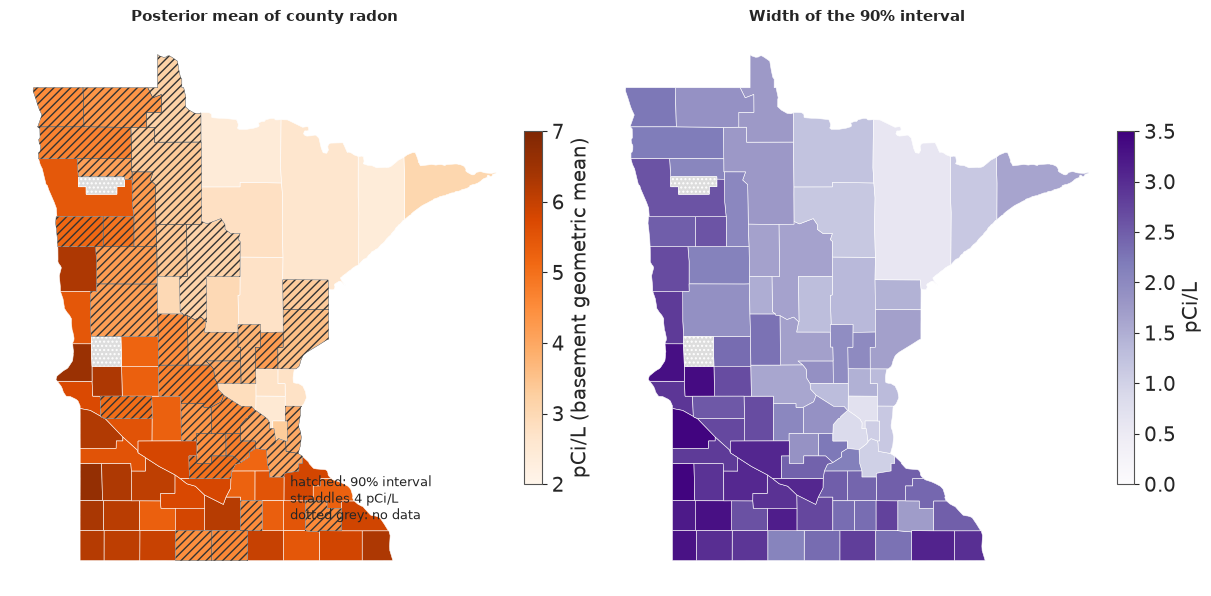

In [18]:
straddles = (gm_lo < 4) & (gm_hi > 4)
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))
draw_map(axes[0], gm_mean, "Oranges", plt.Normalize(2, 7), "Posterior mean of county radon",
         "pCi/L (basement geometric mean)", hatch_mask=straddles)
draw_map(axes[1], gm_hi - gm_lo, "Purples", plt.Normalize(0, 3.5), "Width of the 90% interval", "pCi/L")
axes[0].text(0.55, 0.12, "hatched: 90% interval\nstraddles 4 pCi/L\ndotted grey: no data",
             transform=axes[0].transAxes, fontsize=9);

**Bivariate and value-suppressing palettes.** A bivariate map uses a 3 x 3 palette where
one axis is the value and the other the uncertainty; readers must consult the legend for
every county. Correll, Moritz & Heer's **value-suppressing uncertainty palette** (VSUP, 2018)
changes one thing: as uncertainty grows, adjacent value bins *merge* and fade to grey, so
the map physically refuses to show a distinction the data cannot support. The legend is the
tree at the right: four colours where we are sure, two where we are less sure, one grey where
we are not.

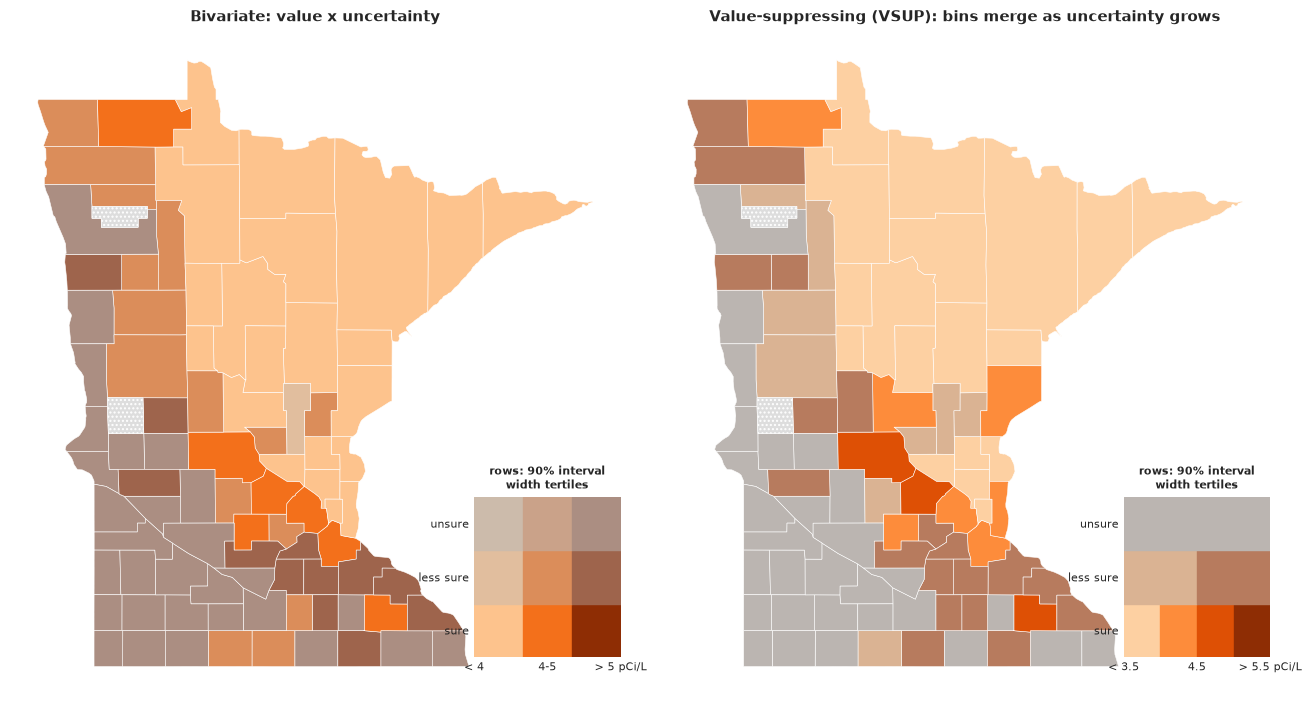

In [19]:
def blend(color, w, grey=(0.72, 0.72, 0.72)):
    """Move `color` a fraction w of the way to grey."""
    c = np.asarray(to_rgb(color))
    return tuple((1 - w) * c + w * np.asarray(grey))


oranges = plt.get_cmap("Oranges")
value_cols = [oranges(v) for v in (0.25, 0.5, 0.72, 0.95)]
value_edges = np.array([3.5, 4.5, 5.5])          # 4 value bins, split at the median for the merged row
width = gm_hi - gm_lo
unc_edges = np.quantile(width, [1 / 3, 2 / 3])   # tertiles of the interval width

vbin = np.digitize(gm_mean, value_edges)         # 0..3
ubin = np.digitize(width, unc_edges)             # 0 sure .. 2 unsure

# Bivariate: 3 value bins (drop the middle split) x 3 uncertainty rows, no merging.
bi_cols = [[blend(c, w) for c in (oranges(0.3), oranges(0.6), oranges(0.95))] for w in (0, 0.4, 0.7)]
vbin3 = np.digitize(gm_mean, [4.0, 5.0])
bivar = [bi_cols[u][v] for u, v in zip(ubin, vbin3)]

# VSUP: row 0 = 4 bins; row 1 = 2 merged bins, half grey; row 2 = one grey cell.
vsup_rows = [
    [blend(c, 0.0) for c in value_cols],
    [blend(np.mean([value_cols[0], value_cols[1]], axis=0)[:3], 0.5),
     blend(np.mean([value_cols[2], value_cols[3]], axis=0)[:3], 0.5)],
    [blend(value_cols[1], 0.95)],
]
vsup = [vsup_rows[u][v if u == 0 else (v // 2 if u == 1 else 0)] for u, v in zip(ubin, vbin)]


def legend_grid(ax, rows, xlabels, ylabels):
    """Rows of coloured cells, each row centred (a 'tree' when rows have different lengths)."""
    for r, row in enumerate(rows):
        w = 4 / len(row)
        for c, col in enumerate(row):
            ax.add_patch(Rectangle((c * w, r), w, 1, color=col))
    ax.set(xlim=(0, 4), ylim=(0, len(rows)), xticks=np.linspace(0, 4, len(xlabels)), yticks=np.arange(len(rows)) + 0.5)
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, colors, name, rows, xl in [
    (axes[0], bivar, "Bivariate: value x uncertainty", bi_cols, ["< 4", "4-5", "> 5 pCi/L"]),
    (axes[1], vsup, "Value-suppressing (VSUP): bins merge as uncertainty grows", vsup_rows, ["< 3.5", "4.5", "> 5.5 pCi/L"]),
]:
    ax.add_collection(PolyCollection([polys[f] for f in county_fips], facecolors=colors, edgecolor="white", linewidth=0.4))
    ax.add_collection(PolyCollection([polys[f] for f in missing_fips], facecolor="#dddddd", edgecolor="white",
                                     linewidth=0.4, hatch="...."))
    ax.autoscale()
    ax.set_aspect(1 / np.cos(np.deg2rad(46)))
    ax.axis("off")
    ax.set_title(name, fontsize=11)
    lax = ax.inset_axes([0.76, 0.06, 0.24, 0.24])  # the empty corner south-east of the arrowhead
    legend_grid(lax, rows, xl, ["sure", "less sure", "unsure"])
    lax.set_title("rows: 90% interval\nwidth tertiles", fontsize=8)

Under the bivariate palette every county has a distinct colour and the reader must decide
whether a pale orange means "moderate and certain" or "high and uncertain". Under the VSUP
the west and the south, where few homes were measured, simply go grey; the reader's eye is
drawn to the counties where the map is allowed to say something.

**The map the decision needs.** If the question is "which counties are likely above the
action level", map *that probability*. It is one number per county, on one sequential hue,
with no separate uncertainty layer because the probability already *is* the uncertainty.

42 counties above 0.9, 16 below 0.1, 27 genuinely undecided (out of 85)


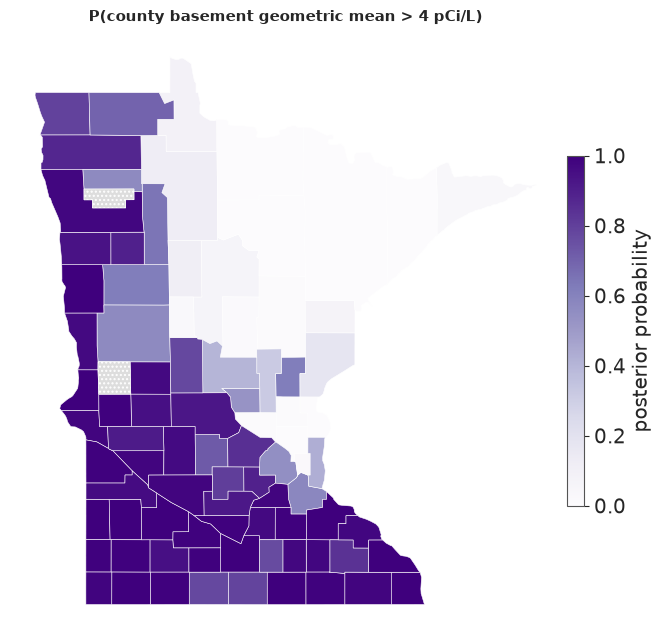

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
draw_map(ax, p_over4, "Purples", plt.Normalize(0, 1),
         "P(county basement geometric mean > 4 pCi/L)", "posterior probability")
print(f"{(p_over4 > 0.9).sum()} counties above 0.9, {(p_over4 < 0.1).sum()} below 0.1, "
      f"{((p_over4 >= 0.1) & (p_over4 <= 0.9)).sum()} genuinely undecided (out of {len(counties)})")

**Draw maps: small multiples of the posterior.** The static counterpart of a HOP: each panel
is one posterior draw of the whole map, on a common colour scale. Counties that change
colour from panel to panel are the uncertain ones; you see uncertainty *and* the spatial
pattern it is uncertain about, with no palette trick at all.

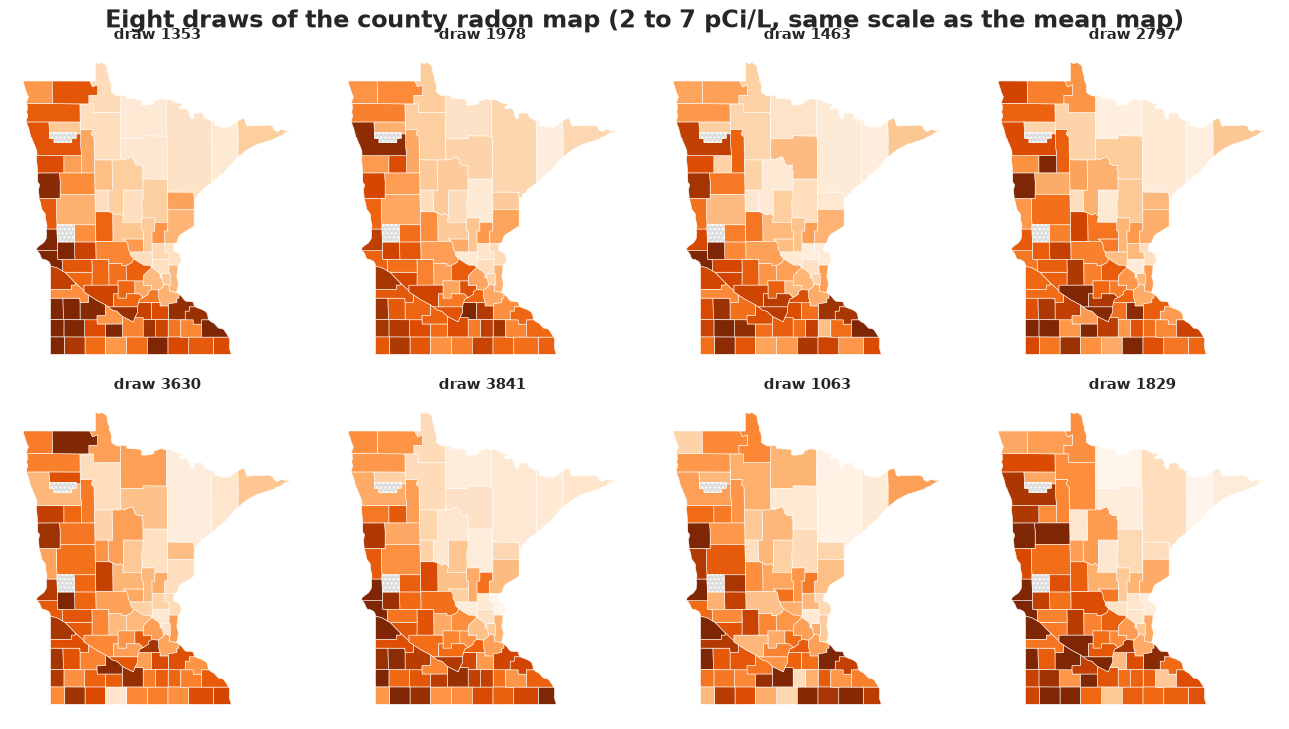

In [21]:
draw_ids = rng.choice(GM.shape[0], 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, d in zip(axes.flat, draw_ids):
    draw_map(ax, GM[d], "Oranges", plt.Normalize(2, 7), f"draw {d}")
fig.suptitle("Eight draws of the county radon map (2 to 7 pCi/L, same scale as the mean map)", y=1.02);

**Interactive and animated maps with plotly.** Plotly draws the same GeoJSON with the
state outline from its built-in US geometry, adds hover, and can animate through posterior
draws (a HOP on a map). The first figure carries the whole posterior summary in its hover
text; the second cycles through 12 draws - press play.

In [22]:
mn_geojson = {"type": "FeatureCollection", "features": list(mn.values())}
county_df = pd.DataFrame({
    "fips": [f"{f:05d}" for f in county_fips], "county": [c.title() for c in counties],
    "mean": gm_mean.round(2), "lo": gm_lo.round(2), "hi": gm_hi.round(2),
    "p_over4": p_over4.round(2), "homes": n_homes,
})
fig = go.Figure(go.Choropleth(
    geojson=mn_geojson, locations=county_df.fips, z=county_df["mean"], zmin=2, zmax=7,
    colorscale="Oranges", marker_line_color="white", marker_line_width=0.5,
    colorbar=dict(title="pCi/L", thickness=12),
    customdata=county_df[["county", "lo", "hi", "p_over4", "homes"]].to_numpy(),
    hovertemplate="<b>%{customdata[0]}</b><br>mean %{z:.1f} pCi/L, 90%% interval %{customdata[1]:.1f}-%{customdata[2]:.1f}"
                  "<br>P(> 4) = %{customdata[3]:.2f}<br>%{customdata[4]} homes measured<extra></extra>",
))
fig.update_geos(fitbounds="locations", visible=False)  # NB: fitbounds is ignored when scope="usa" is set
fig.update_layout(title="County radon: hover for the posterior summary", width=650, height=600,
                  margin=dict(l=0, r=0, t=40, b=0))
fig

In [23]:
anim_ids = rng.choice(GM.shape[0], 12, replace=False)
frames = [go.Frame(name=str(k), data=[go.Choropleth(z=GM[d], locations=county_df.fips)],
                   layout=go.Layout(title_text=f"posterior draw {d}")) for k, d in enumerate(anim_ids)]
fig = go.Figure(
    data=[go.Choropleth(geojson=mn_geojson, locations=county_df.fips, z=GM[anim_ids[0]], zmin=2, zmax=7,
                        colorscale="Oranges", marker_line_color="white", marker_line_width=0.5,
                        colorbar=dict(title="pCi/L", thickness=12), text=county_df.county,
                        hovertemplate="<b>%{text}</b>: %{z:.1f} pCi/L in this draw<extra></extra>")],
    frames=frames,
)
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(
    title_text=f"posterior draw {anim_ids[0]}", width=650, height=620, margin=dict(l=0, r=0, t=40, b=0),
    updatemenus=[dict(type="buttons", x=0.05, y=0.05, buttons=[
        dict(label="play", method="animate",
             args=[None, dict(frame=dict(duration=600, redraw=True), fromcurrent=True, transition=dict(duration=0))]),
        dict(label="pause", method="animate", args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")]),
    ])],
    sliders=[dict(steps=[dict(method="animate", label=str(k),
                              args=[[str(k)], dict(frame=dict(duration=0, redraw=True), mode="immediate")])
                         for k in range(len(frames))], x=0.15, len=0.8, y=0.02)],
)
fig

### 3.4 One homeowner's question: a dotplot and an icon array

The maps summarise counties; a homeowner wants to know about *their* basement. The
predictive distribution for a new home combines the county's uncertainty (large for a
county with two measurements, small for one with a hundred) with the house-to-house spread
$\sigma$, which dominates. A quantile dotplot puts the action level on a countable scale,
and an **icon array** (100 houses, coloured by outcome) is the display that medical
risk communication has found people understand best.

Mille Lacs: n = 2, county GM 3.8 (90%: 2.9-4.8);  Washington: n = 46, county GM 4.0 (90%: 3.4-4.6)


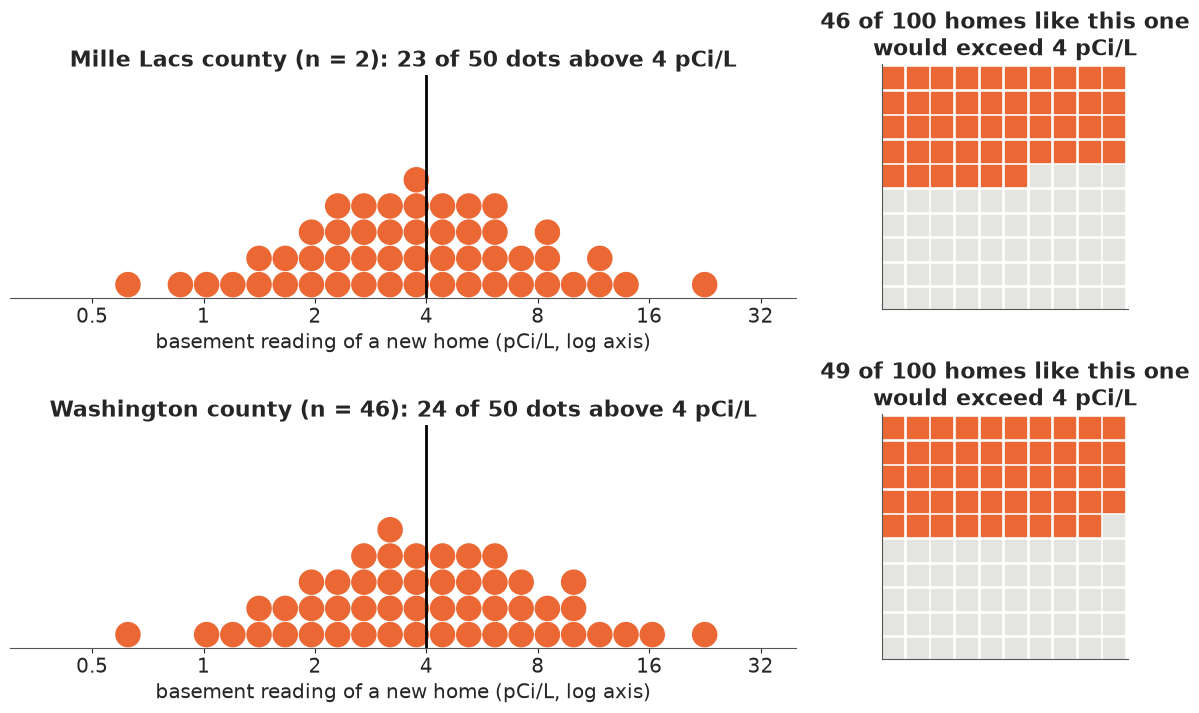

In [24]:
def new_home_reading(county_name, n=4000):
    i = np.where(counties == county_name)[0][0]
    return np.exp(np.log(GM[:n, i]) + rng.normal(0, SIGMA[:n]))


# Two counties with about the same posterior mean but very different sample sizes.
few, many = np.where(n_homes <= 2)[0], np.where(n_homes >= 40)[0]
i_few, i_many = min(((i, j) for i in few for j in many), key=lambda ij: abs(gm_mean[ij[0]] - gm_mean[ij[1]]))
print(f"{counties[i_few].title()}: n = {n_homes[i_few]}, county GM {gm_mean[i_few]:.1f} "
      f"(90%: {gm_lo[i_few]:.1f}-{gm_hi[i_few]:.1f});  {counties[i_many].title()}: n = {n_homes[i_many]}, "
      f"county GM {gm_mean[i_many]:.1f} (90%: {gm_lo[i_many]:.1f}-{gm_hi[i_many]:.1f})")

fig, axes = plt.subplots(2, 2, figsize=(12, 7), gridspec_kw={"width_ratios": [2, 1]})
for row, i in zip(axes, [i_few, i_many]):
    reading = new_home_reading(counties[i])
    p = (reading > 4).mean()
    q = quantile_dotplot(row[0], np.log(reading), n_dots=50, n_bins=30, color=ORANGE,
                         xlim=(np.log(0.3), np.log(40)), max_stack=8)
    row[0].axvline(np.log(4), color="k", lw=2)
    ticks = [0.5, 1, 2, 4, 8, 16, 32]
    row[0].set(xticks=np.log(ticks), xticklabels=ticks, xlabel="basement reading of a new home (pCi/L, log axis)",
               title=f"{counties[i].title()} county (n = {n_homes[i]}): "
                     f"{int((q > np.log(4)).sum())} of 50 dots above 4 pCi/L")
    # icon array: 100 houses, filled in reading order so the count is visible at a glance
    n_over = int(round(100 * p))
    for k in range(100):
        row[1].add_patch(Rectangle((k % 10, 9 - k // 10), 0.85, 0.85,
                                   color=ORANGE if k < n_over else "#e4e4e0"))
    row[1].set(xlim=(0, 10), ylim=(0, 10), xticks=[], yticks=[], aspect="equal",
               title=f"{n_over} of 100 homes like this one\nwould exceed 4 pCi/L")

The two counties have different *county* uncertainty (the 90% interval printed above is
noticeably wider for the one with two homes, even after the uranium predictor has done
its shrinking) and nearly the same *predictive* distribution for a single home, because
the house-to-house spread ($\sigma \approx 0.73$ on the log scale, a factor of two either
way) dominates both. For the homeowner the county's uncertainty is
almost irrelevant - a fact invisible on every county map above, and the strongest argument
for always asking what the reader will do with the figure.

## 4 · Ranks, tables and seasons

### 4.1 Strengths, in the order the league finished

A forest plot of latent strength (attack + defence), sorted by the actual final position.
Where the intervals overlap heavily, the table's order was partly luck.

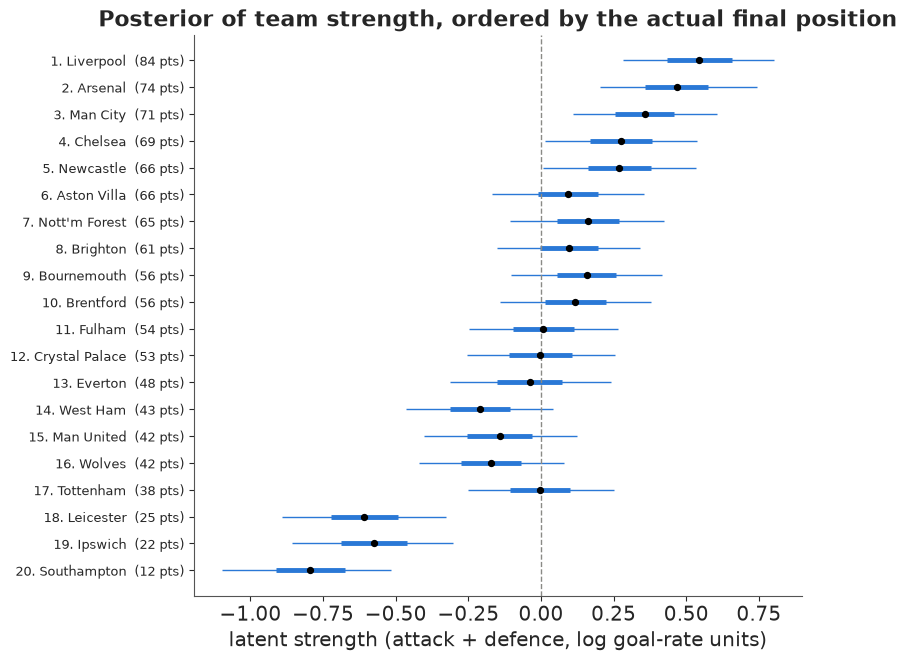

In [25]:
pos_idx = np.argsort(actual_pos)  # team indices, champion first
s_mean = STRENGTH.mean(0)
s50 = np.quantile(STRENGTH, [0.25, 0.75], axis=0)
s90 = np.quantile(STRENGTH, [0.05, 0.95], axis=0)
yy = np.arange(len(teams))[::-1]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.hlines(yy, s90[0, pos_idx], s90[1, pos_idx], color=BLUE, lw=1)
ax.hlines(yy, s50[0, pos_idx], s50[1, pos_idx], color=BLUE, lw=3.5)
ax.scatter(s_mean[pos_idx], yy, color="k", s=18, zorder=3)
ax.set(yticks=yy, xlabel="latent strength (attack + defence, log goal-rate units)",
       title="Posterior of team strength, ordered by the actual final position")
ax.set_yticklabels([f"{p}. {tm}  ({int(actual_pts[i])} pts)" for p, tm, i in
                    zip(range(1, 21), finish_order, pos_idx)], fontsize=9)
ax.axvline(0, color=GREY, lw=1, ls="--");

### 4.2 Rank-probability heatmaps

"Who is the best team" is a question about a **rank**, and the rank of the posterior means
is not the posterior of the rank. Rank the teams in every draw, tabulate, and show the
probability that each team is truly the k-th strongest. The outlined cell is where the team
actually finished.

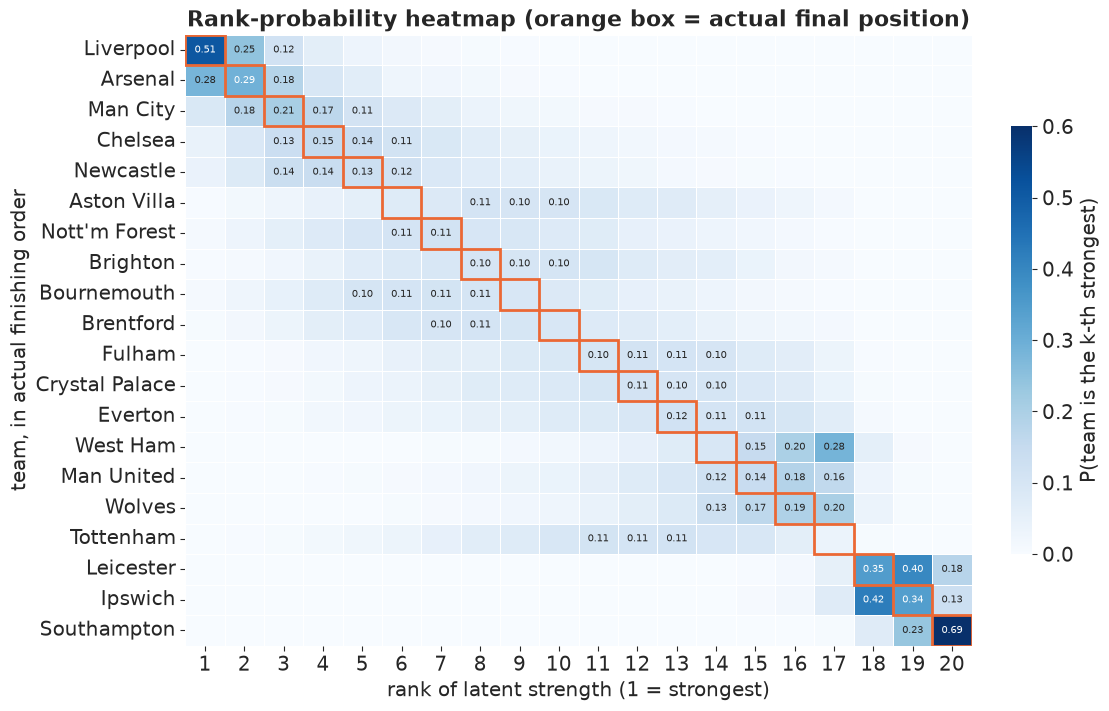

In [26]:
rank_draws = np.argsort(np.argsort(-STRENGTH, axis=1), axis=1) + 1  # (sample, team), 1 = strongest
rank_prob = np.stack([(rank_draws == k).mean(0) for k in range(1, 21)], axis=1)  # (team, rank)
rank_df = pd.DataFrame(rank_prob[pos_idx], index=finish_order, columns=range(1, 21))

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(rank_df, cmap="Blues", vmin=0, vmax=0.6, annot=rank_df.map(lambda v: f"{v:.2f}" if v >= 0.1 else ""),
            fmt="", annot_kws={"size": 7}, cbar_kws={"label": "P(team is the k-th strongest)", "shrink": 0.7},
            linewidths=0.5, linecolor="white", ax=ax)
for r in range(20):
    ax.add_patch(Rectangle((r, r), 1, 1, fill=False, edgecolor=ORANGE, lw=2))
ax.set(xlabel="rank of latent strength (1 = strongest)", ylabel="team, in actual finishing order",
       title="Rank-probability heatmap (orange box = actual final position)")
ax.tick_params(axis="y", rotation=0);

### 4.3 Pairwise "who is stronger" matrix

Rank is a summary of pairwise comparisons, and a pairwise matrix is the honest display of
what the data can and cannot separate: P(row team stronger than column team), on a
diverging palette with a neutral grey at 0.5 (the only place a two-hue palette belongs).
A row that is all dark on one side is a team nobody is close to; a fuzzy block in the middle
of the table is a group the model cannot order.

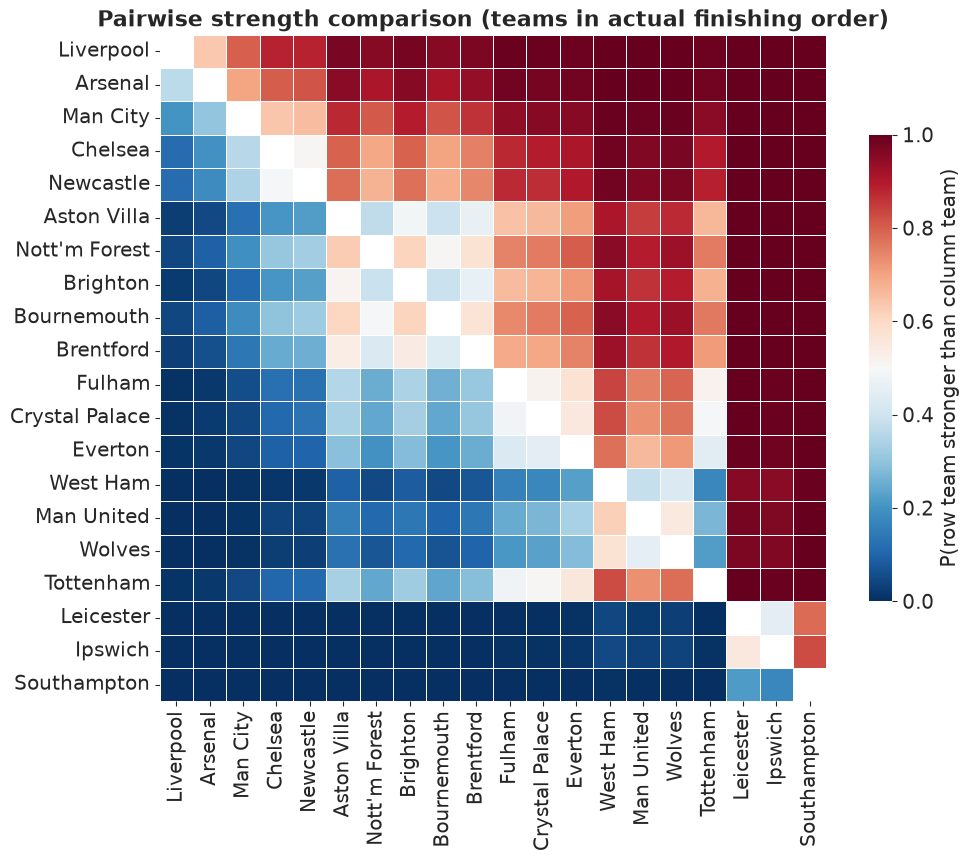

In [27]:
pair = (STRENGTH[:, :, None] > STRENGTH[:, None, :]).mean(0)  # (i, j) = P(i stronger than j)
pair = pair[np.ix_(pos_idx, pos_idx)]
np.fill_diagonal(pair, np.nan)
pair_df = pd.DataFrame(pair, index=finish_order, columns=finish_order)

fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(pair_df, cmap="RdBu_r", center=0.5, vmin=0, vmax=1, square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "P(row team stronger than column team)", "shrink": 0.7}, ax=ax)
ax.set(xlabel="", ylabel="", title="Pairwise strength comparison (teams in actual finishing order)")
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", rotation=0);

### 4.4 Re-simulating the season: outcomes people care about

Fans do not think in log goal-rates. Replay the 380 fixtures under 2000 posterior draws
(Poisson goals from each draw's rates), build 2000 league tables, and the posterior turns
into probabilities of the things that matter: the title, the top four, relegation, and how
many points a team "deserved". This is the posterior predictive of the *season*.

In [28]:
n_sim = 2000
sim = rng.choice(STRENGTH.shape[0], n_sim, replace=False)
lam_h = stacked(epl_idata.posterior["lam_h"])[sim]
lam_a = stacked(epl_idata.posterior["lam_a"])[sim]
gh, ga = rng.poisson(lam_h), rng.poisson(lam_a)
sim_pts, sim_gd, sim_gf = league_table(gh, ga)
sim_pos = ranks_from(sim_pts, sim_gd, sim_gf)  # (n_sim, team)

season = pd.DataFrame({
    "actual points": actual_pts.astype(int),
    "expected points": sim_pts.mean(0).round(1),
    "points 90% interval": [f"{lo:.0f}-{hi:.0f}" for lo, hi in np.quantile(sim_pts, [0.05, 0.95], axis=0).T],
    "luck (actual - expected)": (actual_pts - sim_pts.mean(0)).round(1),
    "P(title)": (sim_pos == 1).mean(0),
    "P(top 4)": (sim_pos <= 4).mean(0),
    "P(relegated)": (sim_pos >= 18).mean(0),
}, index=teams).loc[finish_order]
season.index.name = "team (actual order)"

**When a table is the right display.** Twenty teams by seven quantities is a table, not a
chart - but a table can still carry uncertainty: intervals as text, probabilities as inline
bars, and a diverging colour for the luck column. Round to what the posterior supports
(an expected-points value to one decimal is already generous). Read the luck column with
care: expected points are computed from strengths that partial pooling has pulled towards
the league average, so the extremes of the table look "lucky" and "unlucky" partly by
construction. The team the model singles out is in the middle: Tottenham finished 17th with
the strength of a mid-table side, about 14 points short of what the model expected.

In [29]:
(season.style
 .format({"expected points": "{:.1f}", "luck (actual - expected)": "{:+.1f}",
          "P(title)": "{:.2f}", "P(top 4)": "{:.2f}", "P(relegated)": "{:.2f}"})
 .bar(subset=["P(title)", "P(top 4)", "P(relegated)"], color="#b9d1f0", vmin=0, vmax=1)
 .background_gradient(subset=["luck (actual - expected)"], cmap="RdBu_r", vmin=-15, vmax=15)
 .set_caption("2024/25 re-simulated 2000 times from the posterior"))

,actual points,expected points,points 90% interval,luck (actual - expected),P(title),P(top 4),P(relegated)
team (actual order),,,,,,,
Liverpool,84,73.3,58-88,+10.7,0.40,0.81,0.00
Arsenal,74,68.4,53-84,+5.6,0.19,0.63,0.00
Man City,71,65.6,50-82,+5.4,0.12,0.52,0.00
Chelsea,69,62.4,47-78,+6.6,0.07,0.36,0.01
Newcastle,66,62.2,46-78,+3.8,0.07,0.38,0.00
Aston Villa,66,55.6,40-72,+10.4,0.02,0.14,0.02
Nott'm Forest,65,57.9,42-74,+7.1,0.03,0.22,0.01
Brighton,61,55.8,41-72,+5.2,0.01,0.15,0.02
Bournemouth,56,57.8,41-74,-1.8,0.03,0.21,0.01


**Points distributions with the actual result on top.** The same table as a picture: what
points total the model thought each team was good for, and where they actually landed.

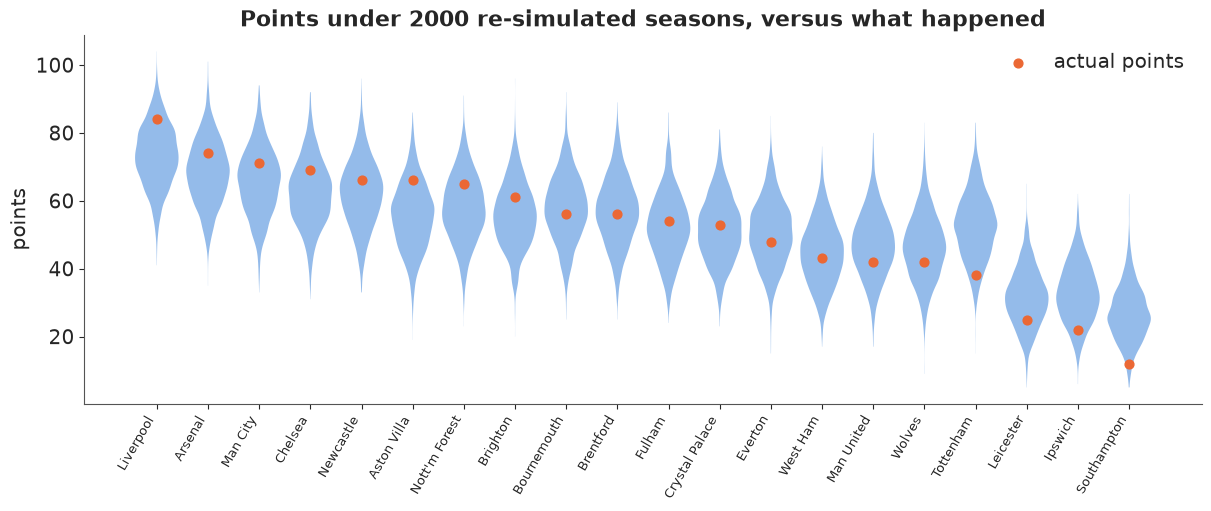

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
parts = ax.violinplot([sim_pts[:, i] for i in pos_idx], positions=np.arange(20), widths=0.85,
                      showextrema=False, showmedians=False)
for body in parts["bodies"]:
    body.set_facecolor(BLUE)
    body.set_alpha(0.5)
ax.scatter(np.arange(20), actual_pts[pos_idx], color=ORANGE, s=40, zorder=3, label="actual points")
ax.set(xticks=np.arange(20), ylabel="points", title="Points under 2000 re-simulated seasons, versus what happened")
ax.set_xticklabels(finish_order, rotation=60, ha="right", fontsize=9)
ax.legend(loc="upper right");

**Animated league tables.** A HOP of the whole season: each frame is one simulated final
table (bars), against the actual points (dots). Teams whose bars leap around between frames
are the ones the model is uncertain about; the top and bottom barely move.

In [31]:
show = rng.choice(n_sim, 25, replace=False)
y_labels = list(finish_order[::-1])
fig = go.Figure(
    data=[go.Bar(x=sim_pts[show[0], pos_idx][::-1], y=y_labels, orientation="h", marker_color=BLUE,
                 name="simulated season", hovertemplate="%{y}: %{x:.0f} pts<extra></extra>"),
          go.Scatter(x=actual_pts[pos_idx][::-1], y=y_labels, mode="markers", name="actual 2024/25",
                     marker=dict(color=ORANGE, size=9), hovertemplate="%{y}: %{x:.0f} pts actual<extra></extra>")],
    frames=[go.Frame(name=str(k), data=[go.Bar(x=sim_pts[s, pos_idx][::-1], y=y_labels, orientation="h")],
                     traces=[0]) for k, s in enumerate(show)],
)
fig.update_layout(
    title="One simulated season per frame (press play)", template="plotly_white", width=800, height=620,
    xaxis=dict(range=[0, 100], title="points"), margin=dict(l=120), legend=dict(orientation="h", y=1.05),
    updatemenus=[dict(type="buttons", x=1.0, y=-0.08, xanchor="right", buttons=[
        dict(label="play", method="animate",
             args=[None, dict(frame=dict(duration=500, redraw=False), fromcurrent=True, transition=dict(duration=200))]),
        dict(label="pause", method="animate", args=[[None], dict(frame=dict(duration=0), mode="immediate")]),
    ])],
)
fig

## 5 · Which display for which question

| The reader asks... | Show | Not |
|---|---|---|
| "Where is the curve / what is the value?" | mean + **labelled** band; say whether it is the mean or a prediction | an unlabelled band |
| "How sure are you?" | fan chart, spaghetti, HOP, quantile dotplot | a single band (read as a cliff) |
| "Could the curve do X?" (a feature) | the posterior of that feature | reading it off a pointwise band |
| "How likely is it beyond a threshold?" | exceedance curve / map, dotplot with the threshold, icon array | a density and a mental integral |
| "Which groups are high / low?" | caterpillar with nested intervals and shrinkage; a mean map | a map of means alone with no uncertainty |
| "Where can I trust the map?" | VSUP, hatching, small-multiple draw maps, an animated map | a bivariate palette without a legend the reader will use |
| "Who is best / what rank?" | rank-probability heatmap, pairwise matrix | ordering the means and calling it the ranking |
| "What will happen?" | re-simulate, then probabilities of the events people care about | parameters on a log scale |
| "Give me the numbers." | a table with intervals, inline bars, sensible rounding | a chart with 140 tiny error bars |

Pitfalls seen above: a pointwise band is not a set of curves and its edges are not
plausible curves; the rank of the means is not the posterior of the ranks; a colour scale
can encode a value *or* uncertainty but needs a designed palette to do both; "no data" is
not "uncertain"; the reader's decision (a homeowner, a fan) often depends on a predictive
distribution that looks nothing like the parameter posterior; and animation is powerful but
neither printable nor accessible to everyone, so ship a static counterpart.

## Try it yourself

1. **Calibrated fans.** Refit the crash model with constant noise (drop `g`) and redraw the
   fan chart of section 2.2. Count the data inside each nested band; which band level is
   the most wrong, and does the exceedance curve of section 2.6 move?
2. **A map of shrinkage.** Map the ratio of the posterior interval width to the width of a
   no-pooling interval (each county on its own). Which counties borrow the most strength,
   and does the VSUP grey out the same ones?
3. **Uncertainty over time.** Refit the league model after 10, 20 and 30 matchdays (filter
   `epl` by date) and animate the rank-probability heatmap over matchdays, or plot
   P(title) for the top three teams as a fan chart against matchday.